#### Name: Solutions

# PHYS 230 Lab Assignment 12

### Wednesday, March 4, 2026: Chapter 6.3.1 - 6.3.4
- Nonlinear equations part 1

In [2]:
# put all import statements here
import math
import numpy as np
import matplotlib.pyplot as plt

## Relaxation Method - 2 variable (25  points)

Use the relaxation method to solve for x and y in the following nonlinear equations: 

$$ 3x - \frac{1}{y} = -1 $$
$$2x^2 - y = 0$$

To do this: 
1) First solve the first equation for $x$ and the second equation for $y$. Put this in a markdown cell. 

2) Make an initial guess for $x$ and $y$ by thinking about one of the equations. 

3) Apply the relaxation method (check class notebook)

4) If it doesn't converge, try solving the opposite equations for $x$ and $y$ and try again. 

*You must clearly comment your code and include a markdown cell explaining your process*

First need to solve for the equations in terms of $x = ...$ and $y = ...$

$$x = -\frac{1}{3}+\frac{1}{3y} \qquad y = 2x^2$$

In [46]:
# choose a number of iterations 
N = 20

# set initial guesses
x = 1.0
y = 2.0

# apply method by plugging values into equations & iterate
for i in range(N):
    x,y = -1/3+1/(3*y), 2*x**2
    print(x,y)

-0.16666666666666666 2.0
-0.16666666666666666 0.05555555555555555
5.666666666666667 0.05555555555555555
5.666666666666667 64.22222222222223
-0.32814302191464817 64.22222222222223
-0.32814302191464817 0.21535568566255453
1.2144936130870203 0.21535568566255453
1.2144936130870203 2.9499894724583298
-0.22033857981119448 2.9499894724583298
-0.22033857981119448 0.09709817950642824
3.099618087874986 0.09709817950642824
3.099618087874986 19.215264581363567
-0.31598601386646397 19.215264581363567
-0.31598601386646397 0.1996943219184343
1.3358845499346959 0.1996943219184343
1.3358845499346959 3.56917506150845
-0.23994107109096077 3.56917506150845
-0.23994107109096077 0.11514343519255499
2.561606641107226 0.11514343519255499
2.561606641107226 13.123657167529288


**Need to find a new function for this that doesn't converge at first**
Not converging, try a different arrangement

$$ y = \frac{1}{3x+1} \qquad x = \sqrt{\frac{y}{2}}$$

In [47]:
# choose a number of iterations 
N = 50

# set initial guesses
x = 1.0
y = 2.0

# apply method by plugging values into equations & iterate
for i in range(N):
    x,y = math.sqrt(y/2), 1/(3*x+1)
    print(x,y)

1.0 0.25
0.3535533905932738 0.25
0.3535533905932738 0.48528137423857026
0.492585715504708 0.48528137423857026
0.492585715504708 0.4035908044526751
0.4492164313850703 0.4035908044526751
0.4492164313850703 0.42595800083497765
0.4614964793121274 0.42595800083497765
0.4614964793121274 0.4193769886711823
0.45791756281626844 0.4193769886711823
0.45791756281626844 0.4212738777995773
0.45895200064907515 0.4212738777995773
0.45895200064907515 0.4207238466195494
0.4586522902044366 0.4207238466195494
0.4586522902044366 0.4208830607863131
0.45873906569329426 0.4208830607863131
0.45873906569329426 0.42083695094408596
0.4587139364266612 0.42083695094408596
0.4587139364266612 0.4208503028289457
0.4587212131725247 0.4208503028289457
0.4587212131725247 0.4208464364024303
0.4587191059910358 0.4208464364024303
0.4587191059910358 0.42084755602504165
0.45871971618028456 0.42084755602504165
0.45871971618028456 0.42084723180855865
0.45871953948385424 0.42084723180855865
0.45871953948385424 0.4208473256939621

## Binary Search (25 pts)

Use the binary search method to find the roots of $f(x) = 5e^{-x} +x -5$. 

To do this: 
1) Start by defining two functions: `f(x)` which returns the given function in the problem and `binary_solve(f,x1,x2,accuracy)` which applies the binary search method for a given function $f(x)$ based on two initial values $x_1, x_2$, and continues to iterate until a given accuracy is achieved. 

2) Call the function and analyze the results. [Use a graph to estimate the interval that returns a non-zero $x$.] 

3) Plot this point as a magenta star on the graph from step 2 to see if it agrees. 


*You must clearly comment your code and include a markdown cell explaining your process*

4.965114233084023
-9.313225746154785e-10


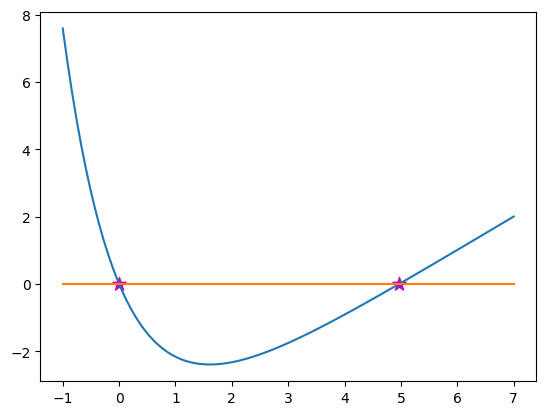

In [12]:
### Code for binary search

# setup so that can put generic function in 
def f(x): 
    return 5*np.exp(-x)+x-5

def binary_solve(f,x1,x2, accuracy):
    # accuracy = target accuracy wanted in evaluted value
    
    # calculate initial values of the function at the boundaries 
    f1 = f(x1)
    f2 = f(x2)
    
    # test to see if f1 and f2 have different signs 
    if f1*f2 < 0: 
        # continue iterative process until difference between x1 and x2 is less than or equal to accuracy
        while x2-x1>accuracy:
            xp = 0.5*(x1+x2)
            fp = f(xp)
            if f1*fp > 0:
                x1,f1 = xp,fp
            else:
                x2,f2 = xp,fp
                
        # once accuracy achieve, calculate resulting value
        result = (0.5*(x1+x2))
        
    else:
        result = -999.99 # if sign of f1 and f2 are the same, return nonsense number 
    
    return result
    
target = 1e-8 # what I want my accuracy to be
x1 = 1.0
x2 = 7.0
# call on binary search method 
answer = binary_solve(f, x1, x2, target)
print(answer)

x1 = -1.0
x2 = 2.0
# call on binary search method 
answer2 = binary_solve(f, x1, x2, target)
print(answer2)

# plot results 
x = np.linspace(-1,7,100)
y = f(x)
y2 = np.zeros(100)
plt.plot(x,y)
plt.plot(x,y2)
plt.scatter(answer,0, color="m", marker="*", s=100)
plt.scatter(answer2,0, color="m", marker="*", s=100)

## Energy of an electron in a square potential well

Consider a square potential well of width $w$, with walls of height $V$: 

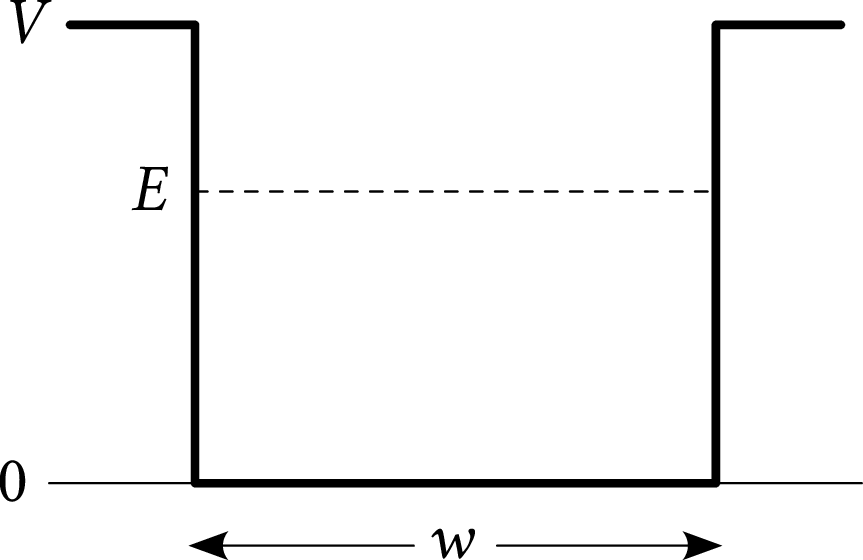

Using Schrödinger's equation, it can be shown that the allowed energies $E$ of a single quantum particle of mass $m$ trapped in the well are solutions of 
$$ \tan{\sqrt{w^2mE/2\hbar^2}} = \begin{cases} 
\sqrt{(V-E)/E} & \text{ for the even numbered states} \\
-\sqrt{E/(V-E)} & \text{ for the odd numbered states} 
\end{cases}
$$

where the states are labeled with integers starting from 0 and working upward, the ground state being state 0, the first excited state being state 1, and so forth. 

a) For an electron of (mass $9.1094 \times 10^{-31}$ kg) in a well with $V = 20 \text{ eV}$ and $w = 1 \text{ nm}$, write a Python program to plot the three quantities 
$$y_1 = \tan{\sqrt{w^2mE/2\hbar^2}} \hspace{0.2in} y_2 = \sqrt{\frac{V-E}{E}} \hspace{0.2in} y_3 = -\sqrt{\frac{E}{V-E}}, $$

on the same graph, as a function of $E$ from $E = 0$ to $E = 20 \text{ eV}$. **Hint** You may find it useful to define functions to calculate $y_1$, $y_2$, and $y_3$. 

b) From your plot make approximate estimates of the energies of the first six energy levels of the particle. 

c) Write a program to calculate the values of the first six energy levels in electron volts to an accuracy of $0.001 \text{ eV}$ using binary search. 

*hint, remember that energies need to be converted to joules in the $y_1$ equation above*

*You must clearly comment your code and include a markdown cell explaining your process*

/var/folders/_7/3rpl5gcd2bg758cn3lr13thn8wg2tc/T/ipykernel_86168/2867488837.py:9: RuntimeWarning: divide by zero encountered in divide
  return np.sqrt((V-E)/E)
/var/folders/_7/3rpl5gcd2bg758cn3lr13thn8wg2tc/T/ipykernel_86168/2867488837.py:12: RuntimeWarning: divide by zero encountered in divide
  return -np.sqrt(E/(V-E))


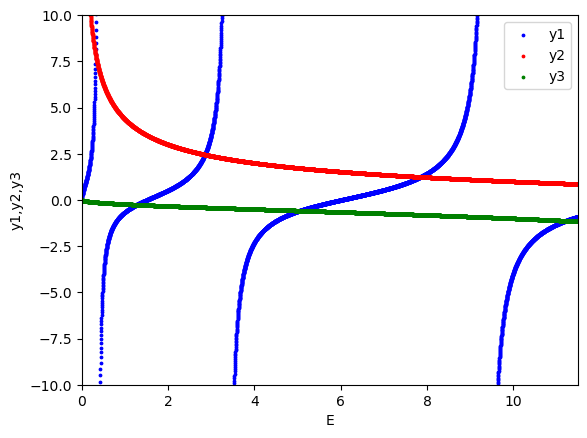

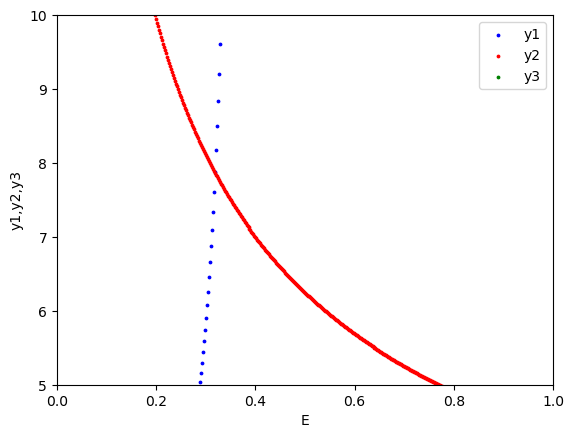

In [32]:
#a) 

def y1(w,m,E):
    hbar = 1.0546e-34   #planck's constant 
    e = 1.6022e-19      # charge of electron 
    return np.tan(np.sqrt(((w**2)*m*E*e)/(2*hbar**2)))

def y2(V,E):
    return np.sqrt((V-E)/E)

def y3(V,E):
    return -np.sqrt(E/(V-E))

m = 9.1094e-31      # mass of electron
E_range = np.linspace(0,20,10000)
V = 20 # eV
w = 1e-9 # 1 nm

y1_vals = y1(w,m,E_range)
y2_vals = y2(V,E_range)
y3_vals = y3(V,E_range)

#print(y1_vals)

plt.scatter(E_range,y1_vals,c="b", s=3, label="y1")
plt.scatter(E_range,y2_vals,c="r", s=3, label="y2")
plt.scatter(E_range,y3_vals,c="g", s=3, label="y3")
plt.ylim(-10,10)
plt.xlim(0,11.5)
plt.xlabel("E")
plt.ylabel("y1,y2,y3")
plt.legend()
plt.show()

plt.figure(2)
plt.scatter(E_range,y1_vals,c="b", s=3, label="y1")
plt.scatter(E_range,y2_vals,c="r", s=3, label="y2")
plt.scatter(E_range,y3_vals,c="g", s=3, label="y3")
plt.ylim(5.0,10)
plt.xlim(0,1.0)
plt.xlabel("E")
plt.ylabel("y1,y2,y3")
plt.legend()
plt.show()


#### b)  The red/green lines seem to cross the blue line at the following points, indicating solutions: E = 0.35, 1.4, 3, 5, 7.8, and 11 (approximately)

In [40]:
#c) 


def binary_solve(f,x1,x2, accuracy):
    # accuracy = target accuracy wanted in evaluted value
    
    # calculate initial values of the function at the boundaries 
    f1 = f(x1)
    f2 = f(x2)
    
    # test to see if f1 and f2 have different signs 
    if f1*f2 < 0: 
        # continue iterative process until difference between x1 and x2 is less than or equal to accuracy
        while x2-x1>accuracy:
            xp = 0.5*(x1+x2)
            fp = f(xp)
            if f1*fp > 0:
                x1,f1 = xp,fp
            else:
                x2,f2 = xp,fp
                
        # once accuracy achieve, calculate resulting value
        result = (0.5*(x1+x2))
        
    else:
        result = -999.99 # if sign of f1 and f2 are the same, return nonsense number 
    
    return result


# need to combine functions from a to work for this binaryt_search function 
def f_even(E): 
    m = 9.1094e-31      # mass of electron
    V = 20 # eV
    w = 1e-9 # 1 nm
    return y1(w,m,E) - y2(V,E)

def f_odd(E): 
    m = 9.1094e-31      # mass of electron
    V = 20 # eV
    w = 1e-9 # 1 nm
    return y1(w,m,E) - y3(V,E)

accuracy = 0.001
print ("E0 = ", binary_solve(f_even,0.2,0.37, accuracy))
print ("E1 = ", binary_solve(f_odd,1.0,2.0, accuracy))
print ("E2 = ", binary_solve(f_even,2.0,3.1, accuracy))
print ("E3 = ", binary_solve(f_odd,4.5,5.5, accuracy))
print ("E4 = ", binary_solve(f_even,7.,9, accuracy))
print ("E5 = ", binary_solve(f_odd,9.5,11.5, accuracy))

E0 =  0.31787109375
E1 =  1.27001953125
E2 =  2.8510498046875
E3 =  5.05029296875
E4 =  7.85009765625
E5 =  11.21533203125
